In [2]:
import os, sys
from glob import glob
from pathlib import Path
import json

import pickle
import numpy as np
import matplotlib.pyplot as plt
# import cv2
from dataclasses import dataclass


@dataclass
class SeamLine :
    segment_idx_arr_list : list
    segment_pos_arr_list : list
    segment_edge_len_arr_list : list
    segment_t_arr_list : list
    segment_u_arr_list : list
    segment_v_arr_list : list
    
@dataclass
class SeamLineScene :
    garment_dir : Path
    garment_version : str = "01"
    
    view_name_list : list = None
    image_dict : dict = None
    seam_annotation_dict : dict = None
    
    def __post_init__(self) :
        self.garment_id_list = str(Path(self.garment_dir).name).split("__")[::2]
    
        self.spec_path_list = []
        for garment_id in self.garment_id_list :
            spec_path = str(Path(self.garment_dir) / f"{garment_id}__{self.garment_version}__specification.json")
            if os.path.exists(spec_path) :
                self.spec_path_list.append(spec_path)
            else :
                spec_path = str(Path(self.garment_dir) / f"{garment_id}_specification.json")
                self.spec_path_list.append(spec_path)
        
        self.stitch_dict_list = []
        for spec_path in self.spec_path_list:
            with open(spec_path, "r") as f:
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]):
                stitch_dict[idx] = stitch
            self.stitch_dict_list.append(stitch_dict)
            
        self.stitch_dict_dict = {}
        for garment_id, spec_path in zip(self.garment_id_list, self.spec_path_list) :
            with open(spec_path, "r") as f :
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]) :
                stitch_dict[idx] = stitch
            self.stitch_dict_dict[garment_id] = stitch_dict
        
        self.garment_count = len(self.spec_path_list)
    
        assert self.check_if_complete(), "Garment Scene is not complete"
    
        self.rendered_path_list = sorted(glob(os.path.join(
            self.garment_dir, "Custom*_1.png"
        )))
        self.view_name_list = list(map(
            lambda x: Path(x).stem[:-2],
            self.rendered_path_list
        ))
        self.rendered_img_dict = dict(zip(
            self.view_name_list,
            list(map(
                lambda x : plt.imread(x),  # cv2.imread(x),
                self.rendered_path_list
            ))
        ))
        
        self.image_dict = {}
        for view_name in self.view_name_list :
            self.image_dict[view_name] = plt.imread(
                str(Path(self.garment_dir) / f"{view_name}.png")
            )
            
        self.seam_annotation_dict = {}
        for view_name in self.view_name_list :
            with open(str(Path(self.garment_dir) / f"{view_name}.pkl"), "rb") as f :
                self.seam_annotation_dict[view_name] = pickle.load(f)

    def check_if_complete(self) :
        rendered_path_list = sorted(glob(os.path.join(
            self.garment_dir, "Custom*_1.png"
        )))
        if len(rendered_path_list) < 10 :
            return False
    
        for rendered_path in rendered_path_list :
            view_name = Path(rendered_path).stem[:-2]
            if not os.path.exists(str(Path(self.garment_dir) / f"{view_name}.pkl")) : return False
            if not os.path.exists(str(Path(self.garment_dir) / f"{view_name}.png")) : return False
            
        return True

In [10]:
# garment_dir_list = sorted(glob(os.path.join(
#     "..", "SAMPLE_DATA", "GCD__GOOD", "*"
# ))) + sorted(glob(os.path.join(
#     "..", "SAMPLE_DATA", "SEWFACTORY__GOOD", "*"
# )))



garment_dir_list = sorted(glob(os.path.join(
    "..", "SAMPLE_DATA", "GCD__02", "*"
))) + sorted(glob(os.path.join(
    "..", "SAMPLE_DATA", "SEWFACTORY__01", "*"
)))

In [11]:
from tqdm import tqdm
import shutil
# scene_list = []

for garment_dir in tqdm(garment_dir_list) :
    try :
        scene = SeamLineScene(
            garment_dir = garment_dir
        )
        # scene_list.append(scene)
        
        tgt_dir = os.path.join(
            "..", "SAMPLE_DATA", "0814", os.path.basename(garment_dir)
        )
        os.makedirs(tgt_dir, exist_ok=True)
        
        for view_name in scene.view_name_list :
            rendered_path = os.path.join(
                garment_dir, f"{view_name}.png"
            )
            annotation_path = os.path.join(
                garment_dir, f"{view_name}.pkl"
            )
            
            shutil.copy(rendered_path, os.path.join(tgt_dir, f"{view_name}.png"))
            shutil.copy(annotation_path, os.path.join(tgt_dir, f"{view_name}.pkl"))
            
        for spec_path in scene.spec_path_list :
            shutil.copy(
                spec_path,
                os.path.join(tgt_dir, os.path.basename(spec_path))
            )
            
                
        
        
    except Exception as e :
        pass
        # print(e)
        

100%|██████████| 907/907 [03:12<00:00,  4.71it/s]


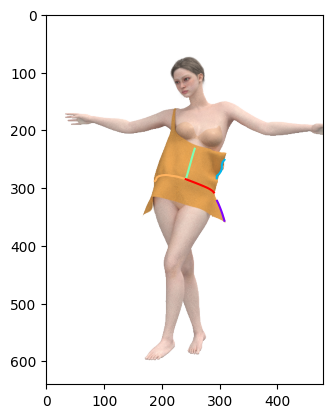

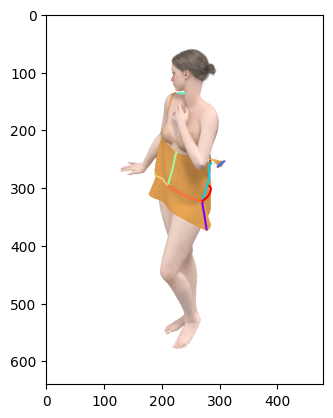

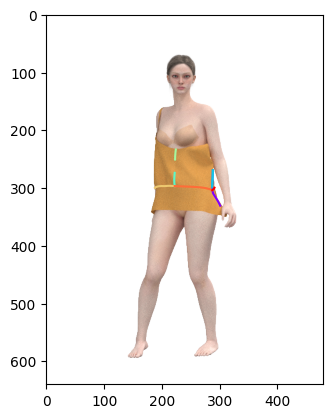

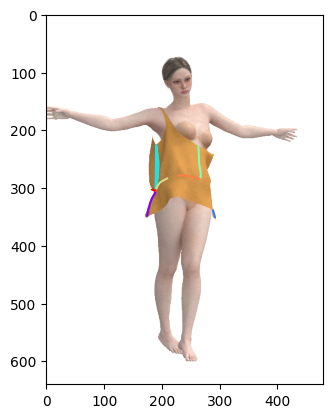

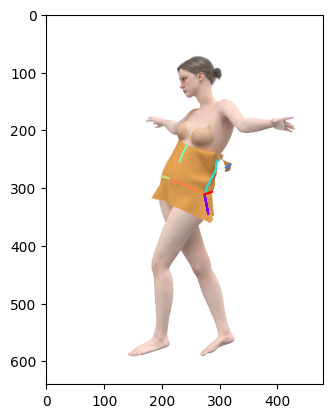

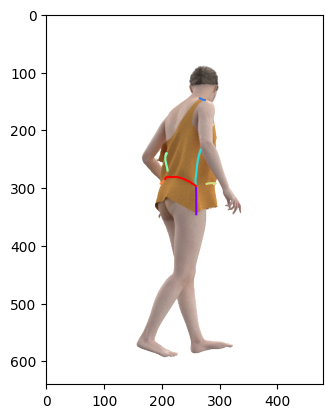

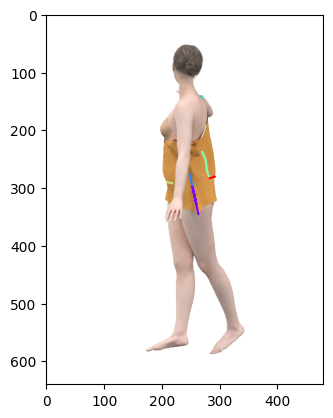

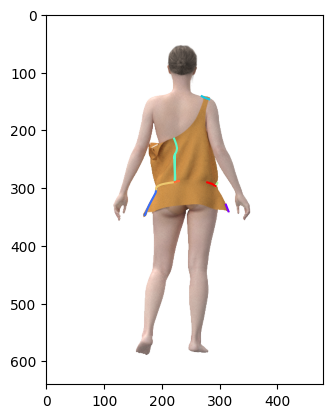

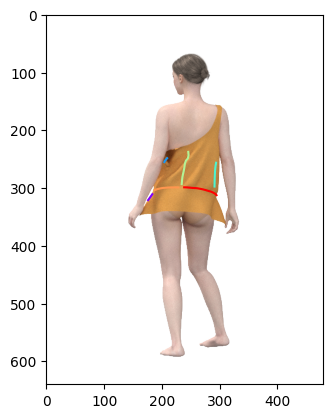

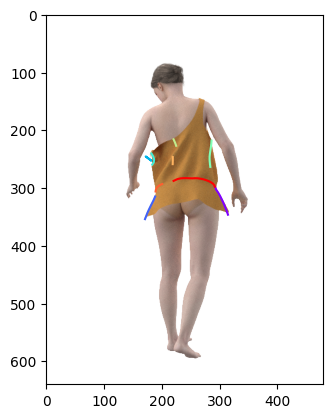

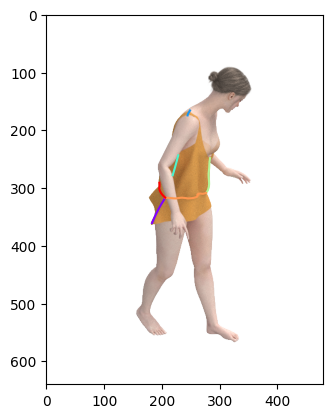

In [6]:
def visualize_seam_annotation_dir(dir) :
    view_name_list = sorted(glob(os.path.join(dir, "*.png")))
    for view_name in view_name_list :
        img = plt.imread(view_name)
        seam_annotation = pickle.load(open(view_name.replace(".png", ".pkl"), "rb"))
        
        plt.imshow(img)

        vis_seam_seg_pos_list = []
        for garment_id in seam_annotation.keys() :
            for stch_idx, sema_line in seam_annotation[garment_id].items() :
                for segment_pos_arr in sema_line['segment_pos_arr_list'] :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            plt.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)
        
        plt.show()



def visualize_seam_annotation_scene(scene) :
    for view_name in scene.view_name_list :
        img = scene.image_dict[view_name]
        seam_annotation = scene.seam_annotation_dict[view_name]
        
        plt.imshow(img)

        vis_seam_seg_pos_list = []
        for garment_id in seam_annotation.keys() :
            for stch_idx, sema_line in seam_annotation[garment_id].items() :
                for segment_pos_arr in sema_line['segment_pos_arr_list'] :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            plt.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)
        
        plt.show()

# visualize_seam_annotation_desktop(scene_list[-1])
visualize_seam_annotation_dir(tgt_dir)